In [1]:
import pypowsybl.network as pn
import pypowsybl.dynamic as dyn
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

In [2]:
from helpers import *

In [3]:
network = pn.load('IEEE14.iidm')
generators = network.get_generators(all_attributes=True)
voltage_levels = network.get_voltage_levels(all_attributes=True)
loads = network.get_loads(all_attributes=True)
buses = network.get_bus_breaker_view_buses(all_attributes=True)

In [4]:
model_mapping = dyn.ModelMapping()

for generatorId, generatorProperties in generators.iterrows():
    voltage_level_id = generators['voltage_level_id'][generatorId]
    nominal_v = voltage_levels['nominal_v'][voltage_level_id]
    if nominal_v == 69.0:
        model_mapping.add_synchronous_generator(static_id=generatorId, parameter_set_id=generatorId, model_name='GeneratorSynchronousFourWindingsProportionalRegulations')
    elif nominal_v == 13.8:
        model_mapping.add_synchronous_generator(static_id=generatorId, parameter_set_id=generatorId, model_name='GeneratorSynchronousThreeWindingsProportionalRegulations')

for loadId, loadsProperties in loads.iterrows():
    model_mapping.add_base_load(static_id=loadId, parameter_set_id='LoadAlphaBeta', model_name='LoadAlphaBeta')

In [5]:
event_mapping = dyn.EventMapping()
event_mapping.add_disconnection(static_id='_BUS____1-BUS____5-1_AC', start_time=1, disconnect_only='TWO')

In [6]:
variables_mapping = dyn.OutputVariableMapping()
variables_mapping.add_standard_model_curves(buses.index[0], 'U_value')
variables_mapping.add_dynamic_model_curves(generators.index[0], 'generator_PGen')

In [7]:
network = pn.load('IEEE14.iidm')
sim = dyn.Simulation()
res = sim.run(network, model_mapping, event_mapping, variables_mapping, 0, 30)

In [8]:
curves = res.curves()
print(curves.columns.tolist())

['NETWORK__BUS___10_TN_U_value', '_GEN____1_SM_generator_PGen']


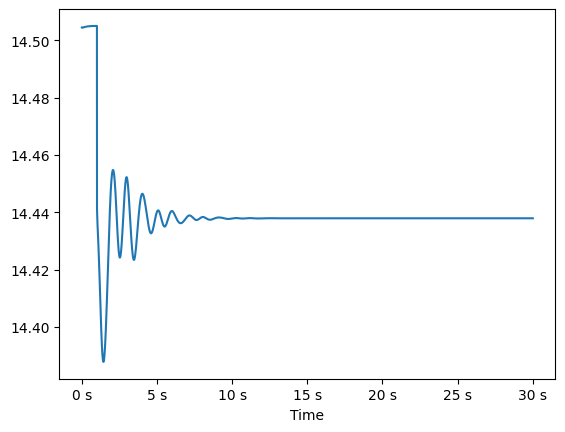

In [13]:
# plot first curve
plot(curves['NETWORK__BUS___10_TN_U_value'])
#plot(curves.iloc[:, 0])

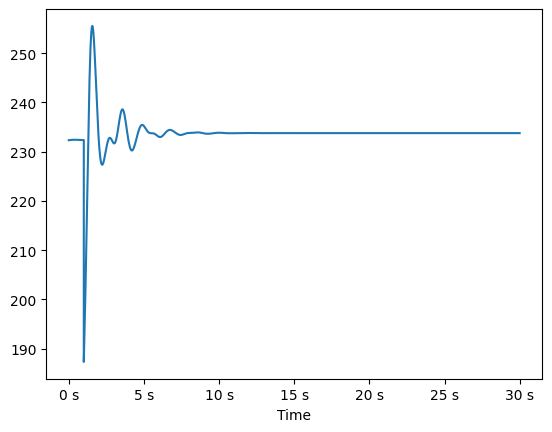

In [14]:
# plot second curve
plot(curves.iloc[:, 1])

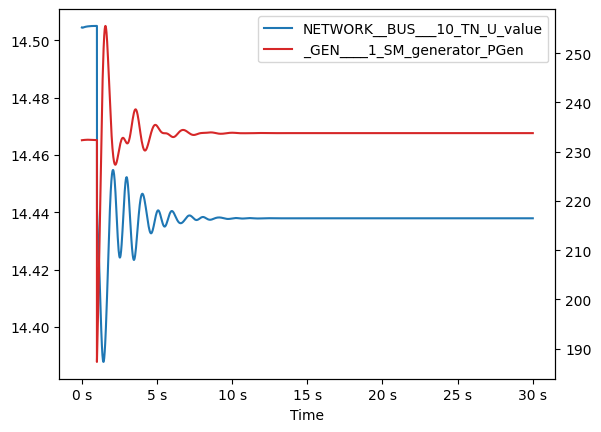

In [17]:
#ax1 = addPlot(curves.iloc[:, 0])
#plotSameGraphDifferentScale(curves.iloc[:, 1], ax1)
ax1 = addPlot(curves['NETWORK__BUS___10_TN_U_value'])
plotSameGraphDifferentScale(curves['_GEN____1_SM_generator_PGen'], ax1)

In [18]:
variables = defineVariables('GeneratorSynchronousFourWindingsProportionalRegulations')
prettyPrintVariables('GeneratorSynchronousFourWindingsProportionalRegulations', variables)

GeneratorSynchronousFourWindingsProportionalRegulations variables:
  generator_IRotorPu_value
  generator_IStatorPu_value
  generator_MdSatPPu
  generator_MqSatPPu
  generator_PGen
  generator_PGenPu
  generator_PePu
  generator_PmPu_value
  generator_QGen
  generator_QGenPu
  generator_QStatorPuQNom_value
  generator_QStatorPu_value
  generator_UPu
  generator_UStatorPu_value
  generator_cePu
  generator_cmPu
  generator_converter_u
  generator_converter_y
  generator_cos2Eta
  generator_efdPu_value
  generator_genState
  generator_iDPu
  generator_iQ1Pu
  generator_iQ2Pu
  generator_iStatorPu_im
  generator_iStatorPu_re
  generator_idPu
  generator_ifPu
  generator_iqPu
  generator_lambdaADPu
  generator_lambdaAQPu
  generator_lambdaAirGapPu
  generator_lambdaDPu
  generator_lambdaQ1Pu
  generator_lambdaQ2Pu
  generator_lambdadPu
  generator_lambdafPu
  generator_lambdaqPu
  generator_mdsPu
  generator_miPu
  generator_mqsPu
  generator_omegaPu_value
  generator_omegaRefPu_value
  ge